# Clean Community loading and simulation 

## 1. Setup

### 1.1 Imports

In [1]:
import sys
sys.path.insert(0, '/home/emma/Dokumente/thesis')

from micom import Community
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from collections import defaultdict
from functions import * 
import cobra 


### 1.2 Paths & reference files

In [2]:
model_dir = "/home/emma/Dokumente/thesis/Model_generation_curation/Curated_models/final"
media_save_dir = "/home/emma/Dokumente/thesis/media_creation/created_media"
community_dir = "/home/emma/Dokumente/thesis/communities/simulations"
media_dir = "/home/emma/Dokumente/thesis/media_creation/created_media"
save_fig_dir = "/home/emma/Dokumente/thesis/git_repository/data/plotsnfigs"

In [3]:
taxonomy_df = pd.read_csv("/home/emma/Dokumente/thesis/communities/SynComs_taxonomy.csv")
met_class = "/home/emma/Dokumente/thesis/media_creation/category_metabolites.csv"

In [4]:
met_class = "/home/emma/Dokumente/thesis/completed_metabolite_classification.csv"
met_class_df = pd.read_csv(met_class)
met_class_dict = dict(zip(met_class_df["Reaction"], met_class_df["Category"]))

In [5]:
af_complete = pd.read_csv("/home/emma/Dokumente/thesis/media_creation/created_media/af_diff_growth/combined_af7_c1i127.csv", names = ["reaction", "flux"])
af_complete_d = create_medium(af_complete)

In [6]:
# define fontsizes and colors
axis_labels = 22
title_size = 26
subtitle_size = 24
legend_size = 22
tick_size = 20

hvsc1_color = "#F2B342"
hvsc2_color = "#317EC2"
shared_color = "#24C136"
color_dict = {"HvSC1": hvsc1_color, "HvSC2": hvsc2_color}


## 2. Create SynCom Communities

In [7]:
HvSC1_df = taxonomy_df[(taxonomy_df["Syncom"] == "HvSC1") | (taxonomy_df["Syncom"] == "Both")]
HvSC1_df = HvSC1_df[["Strain ID","Family"]].rename(columns={'Strain ID': 'id', 'Family': 'family'}).copy()
HvSC1_df["id"] = HvSC1_df["id"].astype(str)
HvSC1_df["abundance"] = 1
HvSC1_df["file"] = HvSC1_df['id'].apply(lambda x: f"{model_dir}/{x}_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix.xml")

In [8]:
HvSC2_df = taxonomy_df[(taxonomy_df["Syncom"] == "HvSC2") | (taxonomy_df["Syncom"] == "Both")]
HvSC2_df = HvSC2_df[["Strain ID","Family"]].rename(columns={'Strain ID': 'id', 'Family': 'family'}).copy()
HvSC2_df["id"] = HvSC2_df["id"].astype(str)
HvSC2_df["abundance"] = 1
HvSC2_df["file"] = HvSC2_df['id'].apply(lambda x: f"{model_dir}/{x}_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix.xml")

In [9]:
HvSC1 = Community(HvSC1_df, id = "HvSC1", name = "HvSC1")

Output()

In [10]:
HvSC2 = Community(HvSC2_df, id = "HvSC2", name = "HvSC2")

Output()

## 3. Simulate Communities

In [11]:
fraction = [1]

In [12]:
HvSC1.medium = af_complete_d

In [13]:
HvSC2.medium = af_complete_d

In [14]:
solution_sc1 = run_l2_then_pfba(HvSC1, fractions=fraction)

optimal solution: 7.535269930920041
---------
Tradeoff-value: 1
Community objective: 7.534438744858953
pFBA solution (total flux): 206897.36409788157
---------


In [15]:
solution_sc2 = run_l2_then_pfba(HvSC2, fractions=fraction)

optimal solution: 5.94610871199841
---------
Tradeoff-value: 1
Community objective: 5.945426027918952
pFBA solution (total flux): 212727.49835064827
---------


### 3.1 Analyse and plot individual growth rates

In [7]:
gr_sc1 = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/pfba/HvSC1_l2pfba_10_individualtaxon_growth.csv")
gr_sc2 = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/pfba/HvSC2_l2pfba_10_individualtaxon_growth.csv")

In [8]:
#gr_sc1 = solution_sc1.iloc[0]["solution"].members.drop("medium")
#gr_sc2 = solution_sc2.iloc[0]["solution"].members.drop("medium")

gr_sc1["scaled_growth"] = gr_sc1["growth_rate"] * (1/len(gr_sc1["growth_rate"]))
gr_sc2["scaled_growth"] = gr_sc2["growth_rate"] * (1/len(gr_sc2["growth_rate"]))

In [9]:
avg_growth_sc1 = gr_sc1["scaled_growth"].median()
avg_growth_sc2 = gr_sc2["scaled_growth"].median()

iqr_sc1 = gr_sc1["scaled_growth"].quantile(0.75) - gr_sc1["scaled_growth"].quantile(0.25)
iqr_sc2 = gr_sc2["scaled_growth"].quantile(0.75) - gr_sc2["scaled_growth"].quantile(0.25)

print(f"HvSC1 - Median: {avg_growth_sc1:.4f}, IQR: {iqr_sc1:.4f}")
print(f"HvSC2 - Median: {avg_growth_sc2:.4f}, IQR: {iqr_sc2:.4f}")

HvSC1 - Median: 0.2362, IQR: 0.0360
HvSC2 - Median: 0.2123, IQR: 0.0889


In [10]:
combined_gr = pd.concat([gr_sc1.assign(syncom="HvSC1"), gr_sc2.assign(syncom="HvSC2")], ignore_index=True).dropna(subset=["scaled_growth"])
combined_gr = combined_gr.set_index("compartments")

target_ids = ["1234", "1334", "1174"]

bg_data = combined_gr[~combined_gr.index.isin(target_ids)]
highlight_data = combined_gr[combined_gr.index.isin(target_ids)]

/tmp/ipykernel_7218/1172314128.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


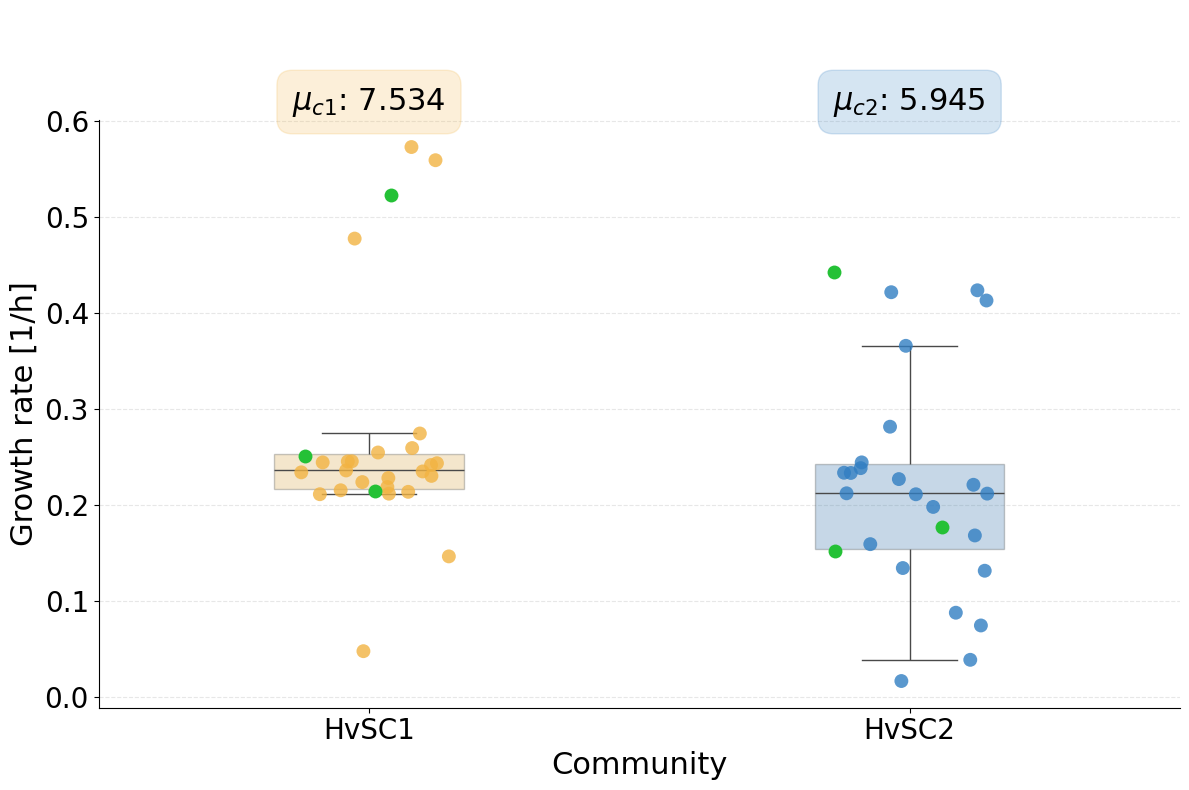

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))

# 1. Boxplot
sns.boxplot(
    data=combined_gr,
    x="syncom", y="scaled_growth",
    palette=color_dict,
    width=0.35,
    boxprops=dict(alpha=0.3),
    showcaps=True, showfliers=False,
    ax=ax) 

# 2. Main Stripplot
sns.stripplot(
    data=bg_data,
    x="syncom", y="scaled_growth",
    hue="syncom",
    palette=color_dict,
    jitter=0.15,
    alpha=0.8,
    size=10,
    ax=ax,
    legend=False) 

# 3. Highlight Stripplot
sns.stripplot(
    data=highlight_data,
    x="syncom", y="scaled_growth",
    color=shared_color, 
    jitter=0.15,
    ax=ax,
    size = 10,
    legend=False)

ax.text(x=0, y=0.62, 
    s="$\mu_{c1}$: 7.534", 
    ha="center", va="center",
    fontsize=legend_size,
    bbox=dict(boxstyle="round,pad=0.5", facecolor=hvsc1_color, alpha=0.2, edgecolor=hvsc1_color))
ax.text(x=1, y=0.62, 
    s="$\mu_{c2}$: 5.945", 
    ha="center", va="center",
    fontsize=legend_size,
    bbox=dict(boxstyle="round,pad=0.5", facecolor=hvsc2_color, alpha=0.2, edgecolor=hvsc2_color))

ax.set_title(" ", fontsize=title_size, pad=60)
ax.set_xlabel("Community", fontsize=axis_labels)
ax.set_ylabel("Growth rate [1/h]", fontsize=axis_labels)

ax.tick_params(axis="both", labelsize=tick_size)
ax.grid(True, linestyle="--", alpha=0.3, axis="y")
sns.despine(ax=ax)

plt.tight_layout()
fp = os.path.join(save_fig_dir, "Individual_growthrates_boxplot_l2pfba_nolabels.svg")

fp = os.path.join(save_fig_dir, "Individual_growthrates_boxplot_l2pfba_nolabels.png")
plt.savefig(fp, bbox_inches='tight')
plt.show()

### 3.2. Metabolic niches - MRO score

In [10]:
def filter_h2o_h_o2(df):
    mets2filter = ["EX_h2o_e", "EX_o2_e", "EX_h_e", "EX_h2_e"]
    filtered_df = df[df["reaction"].apply(lambda x: x not in mets2filter)]
    return filtered_df

In [11]:
# load fluxes from community simulations
HvSC1_fluxes1 = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/pfba/HvSC1_l2pfba_10_fluxes.csv", index_col= "compartment")
HvSC2_fluxes1 = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/pfba/HvSC2_l2pfba_10_fluxes.csv", index_col = "compartment")


In [12]:
HvSC1_fluxes1_clean = tidy_exchange_fluxes(HvSC1_fluxes1)
HvSC2_fluxes1_clean = tidy_exchange_fluxes(HvSC2_fluxes1)

HvSC1_fluxes1_clean = filter_h2o_h_o2(HvSC1_fluxes1_clean)
HvSC2_fluxes1_clean = filter_h2o_h_o2(HvSC2_fluxes1_clean)

In [13]:
active_exchanges_sc1 = HvSC1_fluxes1_clean[HvSC1_fluxes1_clean["taxon"] != "medium"]
active_exchanges_sc2 = HvSC2_fluxes1_clean[HvSC2_fluxes1_clean["taxon"] != "medium"]

# Community 1
summary_exchanges_sc1 = active_exchanges_sc1.groupby(["taxon", "direction"])["flux"].agg(count="count", sum_flux="sum").unstack(fill_value=0)
summary_exchanges_sc1.columns = [f"{metric}_{direction.replace('import', 'uptakes').replace('export', 'secretions')}" for metric, direction in summary_exchanges_sc1.columns]
summary_exchanges_sc1 = summary_exchanges_sc1.reindex(columns=["count_uptakes", "sum_flux_uptakes", "count_secretions", "sum_flux_secretions"], fill_value=0).sort_values(by="count_uptakes", ascending=False)

# Community 2
summary_exchanges_sc2 = active_exchanges_sc2.groupby(["taxon", "direction"])["flux"].agg(count="count", sum_flux="sum").unstack(fill_value=0)
summary_exchanges_sc2.columns = [f"{metric}_{direction.replace('import', 'uptakes').replace('export', 'secretions')}" for metric, direction in summary_exchanges_sc2.columns]
summary_exchanges_sc2 = summary_exchanges_sc2.reindex(columns=["count_uptakes", "sum_flux_uptakes", "count_secretions", "sum_flux_secretions"], fill_value=0).sort_values(by="count_uptakes", ascending=False)

# only negative fluxes (uptakes)
uptake_sc1 = active_exchanges_sc1[active_exchanges_sc1["direction"] == "import"].sort_values(by="flux", ascending = False)
uptake_sc2 = active_exchanges_sc2[active_exchanges_sc2["direction"] == "import"].sort_values(by="flux", ascending = False)

# only positive fluxes (secretions)
secrete_sc1 = active_exchanges_sc1[active_exchanges_sc1["direction"] == "export"]
secrete_sc2 = active_exchanges_sc2[active_exchanges_sc2["direction"] == "export"]

In [14]:
taxa_uptakes_sc1 = uptake_sc1.groupby("taxon")["reaction"].apply(set)
taxa_uptakes_sc2 = uptake_sc2.groupby("taxon")["reaction"].apply(set)

In [16]:
mro_sc1 = mro_score(taxa_uptakes_sc1)
mro_sc2 = mro_score(taxa_uptakes_sc2)

print(f"MRO score: {mro_sc1} HvSC1, {mro_sc2} HvSC2")

MRO score: 0.5119136326615489 HvSC1, 0.5014171750351948 HvSC2


In [17]:
# metabolic requirements of each strain in the communities - compare the width of resource requirements

sc1_uptake_counts = uptake_sc1.groupby("taxon")["reaction"].nunique()
sc2_uptake_counts = uptake_sc2.groupby("taxon")["reaction"].nunique()

print(f"Average number of unique uptakes per taxon: {sc1_uptake_counts.median()} HvSC1, {sc2_uptake_counts.median()} HvSC2")

Average number of unique uptakes per taxon: 162.0 HvSC1, 155.5 HvSC2


### 3.3 Interaction analysis

#### 3.3.1 Create interaction dataframes

In [15]:
interact_sc1_1 = get_interactions(HvSC1_fluxes1_clean)
interact_sc2_1 = get_interactions(HvSC2_fluxes1_clean)

/home/emma/Dokumente/thesis/functions.py:629: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: classify_interaction(df, taxon, p, abundance))
/home/emma/Dokumente/thesis/functions.py:629: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: classify_interaction(df, taxon, p, abundance))
/home/emma/Dokumente/thesis/functions.py:629: FutureWarning: DataFrameGroupBy.apply operated on the groupi

In [20]:
interact_sc1_1.to_csv("/home/emma/Dokumente/thesis/communities/simulations/pfba/HvSC1_l2pfba_10_interactions.csv")
interact_sc2_1.to_csv("/home/emma/Dokumente/thesis/communities/simulations/pfba/HvSC2_l2pfba_10_interactions.csv")

In [16]:
mets2filter = ["EX_h2o_e", "EX_o2_e", "EX_h_e"]
metsfiltered_sc1 = interact_sc1_1[interact_sc1_1["reaction"].apply(lambda x: x not in mets2filter)]
metsfiltered_sc2 = interact_sc2_1[interact_sc2_1["reaction"].apply(lambda x: x not in mets2filter)]

In [17]:
filtered_sc1 = metsfiltered_sc1[(metsfiltered_sc1["class"] == "received") | (metsfiltered_sc1["class"] == "provided")]
filtered_sc2 = metsfiltered_sc2[(metsfiltered_sc2["class"] == "received") | (metsfiltered_sc2["class"] == "provided")]

In [18]:
coconsumption_sc1 = metsfiltered_sc1[(metsfiltered_sc1["class"] == "co-consumed")]
coconsumption_sc2 = metsfiltered_sc2[(metsfiltered_sc2["class"] == "co-consumed")]

#### 3.3.2 - MIP and fMIP score

In [42]:
medup_sc1, medup_sc1_list, comup_sc1, mip = uptake_mediumvscommunity(uptake_sc1, af_complete_d)
medup_sc2, medup_sc2_list, comup_sc2, mip2 = uptake_mediumvscommunity(uptake_sc2, af_complete_d)

print(f"HvSC1: {medup_sc1} from medium (exluding h20, h2 and o2), {comup_sc1} from com, MIP: {mip}")
print(f"HvSC2: {medup_sc2} from medium (exluding h20, h2 and o2), {comup_sc2} from com, MIP: {mip2}")

HvSC1: 47 from medium (exluding h20, h2 and o2), 483 from com, MIP: 0.9113207547169812
HvSC2: 47 from medium (exluding h20, h2 and o2), 499 from com, MIP: 0.9139194139194139


In [34]:
medium_rxns = {rxn[:-2] + "_e" if isinstance(rxn, str) and rxn.endswith("_m") else rxn for rxn in af_complete_d.keys()}

In [44]:
# not uptaken from medium
n1 = medium_rxns - set(medup_sc1_list)
n2 = medium_rxns - set(medup_sc2_list)

In [38]:
fall_sc1, fcom_sc1 , fmip1 = fMIP(uptake_sc1, af_complete_d)
fall_sc2, fcom_sc2, fmip2 = fMIP(uptake_sc2, af_complete_d)

print(f"HvSC1: {fall_sc1} total , {fcom_sc1} from medium, fMIP: {fmip1}")
print(f"HvSC2: {fall_sc2} total, {fcom_sc2} from medium, fMIP: {fmip2}")

HvSC1: -7915.471070024095 total , -4939.3518498383855 from medium, fMIP: 0.37598763154555376
HvSC2: -10604.650093208536 total, -5630.655722969763 from medium, fMIP: 0.4690389901147455


#### 3.3.3 Use dataframes from 3.3.1 to analyse metabolic interactions

##### Co-consumption

In [19]:
df_clean1 = coconsumption_sc1.copy()
df_clean1['producer'] = df_clean1['focal'].astype(str).str.split("_").str[0]
df_clean1['consumer'] = df_clean1['partner'].astype(str).str.split("_").str[0]

df_clean2 = coconsumption_sc2.copy()
df_clean2['producer'] = df_clean2['focal'].astype(str).str.split("_").str[0]
df_clean2['consumer'] = df_clean2['partner'].astype(str).str.split("_").str[0]

# Group by strains and count unique metabolites exchanged 
matrix_df1 = df_clean1.groupby(['producer', 'consumer'], as_index=False)['reaction'].nunique()
matrix_df1.rename(columns={'reaction': 'number_exchanges'}, inplace=True)
matrix_df2 = df_clean2.groupby(['producer', 'consumer'], as_index=False)['reaction'].nunique()
matrix_df2.rename(columns={'reaction': 'number_exchanges'}, inplace=True)

# Build Pivoted Heatmap Matrices 
heatmap_matrix1_cc = matrix_df1.pivot(index='producer', columns='consumer', values='number_exchanges').fillna(0)
heatmap_matrix2_cc = matrix_df2.pivot(index='producer', columns='consumer', values='number_exchanges').fillna(0)

In [20]:
avg_sc1 = matrix_df1['number_exchanges'].mean()
avg_sc2 = matrix_df2['number_exchanges'].mean()

print(f"Average co-consumed metabolites: {avg_sc1} (HvSC1), {avg_sc2} (HvSC2)")

Average co-consumed metabolites: 43.84615384615385 (HvSC1), 39.72615384615385 (HvSC2)


In [21]:
# Find the overall min and max between both datasets
min_val = min(heatmap_matrix1_cc.values.min(), heatmap_matrix2_cc.values.min())
max_val = max(heatmap_matrix1_cc.values.max(), heatmap_matrix2_cc.values.max())

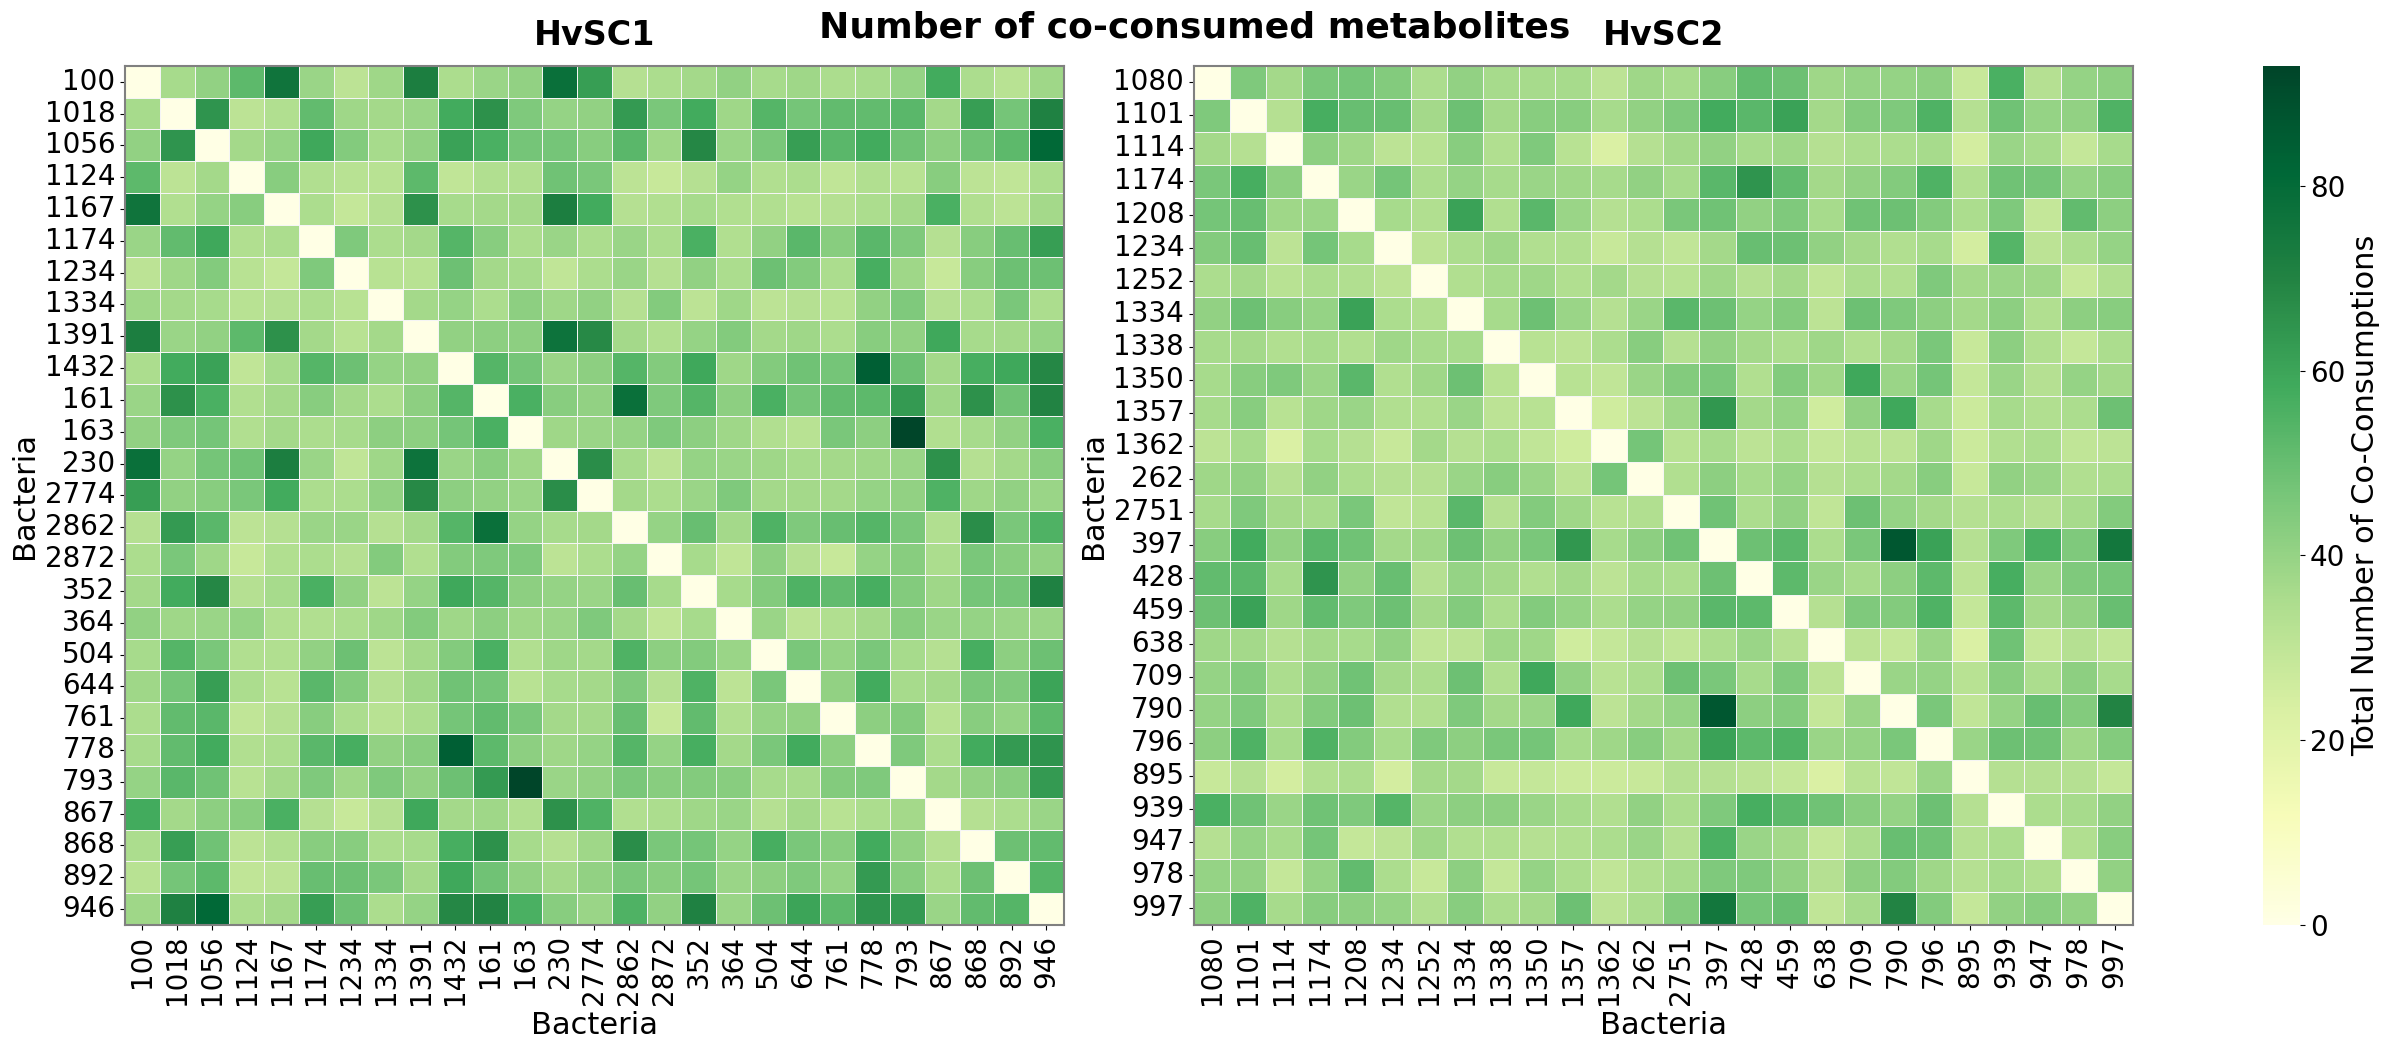

In [22]:
fig, (ax1, ax2, cbar_ax) = plt.subplots(
    1, 3, 
    figsize= (24, 11), 
    sharey=False,
    gridspec_kw={'width_ratios': [1, 1, 0.04]}
)
fig.suptitle("Number of co-consumed metabolites", fontsize=title_size, fontweight='bold', y=0.95)

sns.heatmap(
    heatmap_matrix1_cc, 
    ax=ax1,               
    cmap="YlGn", 
    robust=True,            
    vmin=min_val,               
    vmax=max_val,   
    cbar = False,             
    linewidths=0.5,         
    linecolor='whitesmoke'
)

ax1.set_title("HvSC1", fontsize=subtitle_size, fontweight='bold', pad=15)
ax1.tick_params(labelsize=tick_size, axis = "both")
ax1.set_xlabel("Bacteria", fontsize=axis_labels)
ax1.set_ylabel("Bacteria", fontsize=axis_labels)


for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_color('grey')
    spine.set_linewidth(1.5)

sns.heatmap(
    heatmap_matrix2_cc, 
    ax=ax2,                     
    cmap="YlGn", 
    cbar_ax= cbar_ax,        
    robust=True,            
    vmin=min_val,                
    vmax=max_val,               
    cbar_kws={'label': 'Total Number of Co-Consumptions'},
    linewidths=0.5,         
    linecolor='whitesmoke'
)

ax2.set_title("HvSC2", fontsize=subtitle_size, fontweight='bold', pad=15)
ax2.tick_params(labelsize=tick_size, axis = "both")
ax2.set_xlabel("Bacteria", fontsize=axis_labels)
ax2.set_ylabel("Bacteria", fontsize=axis_labels)

cbar = ax2.collections[0].colorbar
cbar.set_label('Total Number of Co-Consumptions', size=legend_size)
cbar.ax.tick_params(labelsize=tick_size)

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_color('grey')
    spine.set_linewidth(1.5)

plt.tight_layout() 
fp = os.path.join(save_fig_dir+"Combined_Numbercoconsumptions_heatmap.png")
plt.savefig(fp)
plt.show()

##### Pairwise Metabolic Interaction in Absolute Numbers

In [23]:
df_clean1 = filtered_sc1.copy()
df_clean1['producer'] = df_clean1['focal'].astype(str).str.split("_").str[0]
df_clean1['consumer'] = df_clean1['partner'].astype(str).str.split("_").str[0]

df_clean2 = filtered_sc2.copy()
df_clean2['producer'] = df_clean2['focal'].astype(str).str.split("_").str[0]
df_clean2['consumer'] = df_clean2['partner'].astype(str).str.split("_").str[0]

# Group by strains and count unique metabolites exchanged as well as sum of fluxes
matrix_nex_df1 = df_clean1.groupby(['producer', 'consumer'], as_index=False)['reaction'].nunique()
matrix_nex_df1.rename(columns={'reaction': 'number_exchanges'}, inplace=True)
matrix_sumflux_df1 = df_clean1.groupby(['producer', 'consumer'], as_index=False)['flux'].sum()
matrix_sumflux_df1.rename(columns={'flux': 'sum_fluxes'}, inplace=True)

matrix_nex_df2 = df_clean2.groupby(['producer', 'consumer'], as_index=False)['reaction'].nunique()
matrix_nex_df2.rename(columns={'reaction': 'number_exchanges'}, inplace=True)
matrix_sumflux_df2 = df_clean2.groupby(['producer', 'consumer'], as_index=False)['flux'].sum()
matrix_sumflux_df2.rename(columns={'flux': 'sum_fluxes'}, inplace=True)

# Build Pivoted Heatmap Matrices
heatmap_nex_matrix1 = matrix_nex_df1.pivot(index='producer', columns='consumer', values='number_exchanges').fillna(0)
heatmap_nex_matrix2 = matrix_nex_df2.pivot(index='producer', columns='consumer', values='number_exchanges').fillna(0)

heatmap_sumflux_matrix1 = matrix_sumflux_df1.pivot(index='producer', columns='consumer', values='sum_fluxes').fillna(0)
heatmap_sumflux_matrix2 = matrix_sumflux_df2.pivot(index='producer', columns='consumer', values='sum_fluxes').fillna(0)

In [24]:
# Find the overall min and max between both datasets
min_nex_val = min(heatmap_nex_matrix1.values.min(), heatmap_nex_matrix2.values.min())
max_nex_val = max(heatmap_nex_matrix1.values.max(), heatmap_nex_matrix2.values.max())

min_sumflux_val = min(heatmap_sumflux_matrix1.values.min(), heatmap_sumflux_matrix2.values.min())
max_sumflux_val = max(heatmap_sumflux_matrix1.values.max(), heatmap_sumflux_matrix2.values.max())

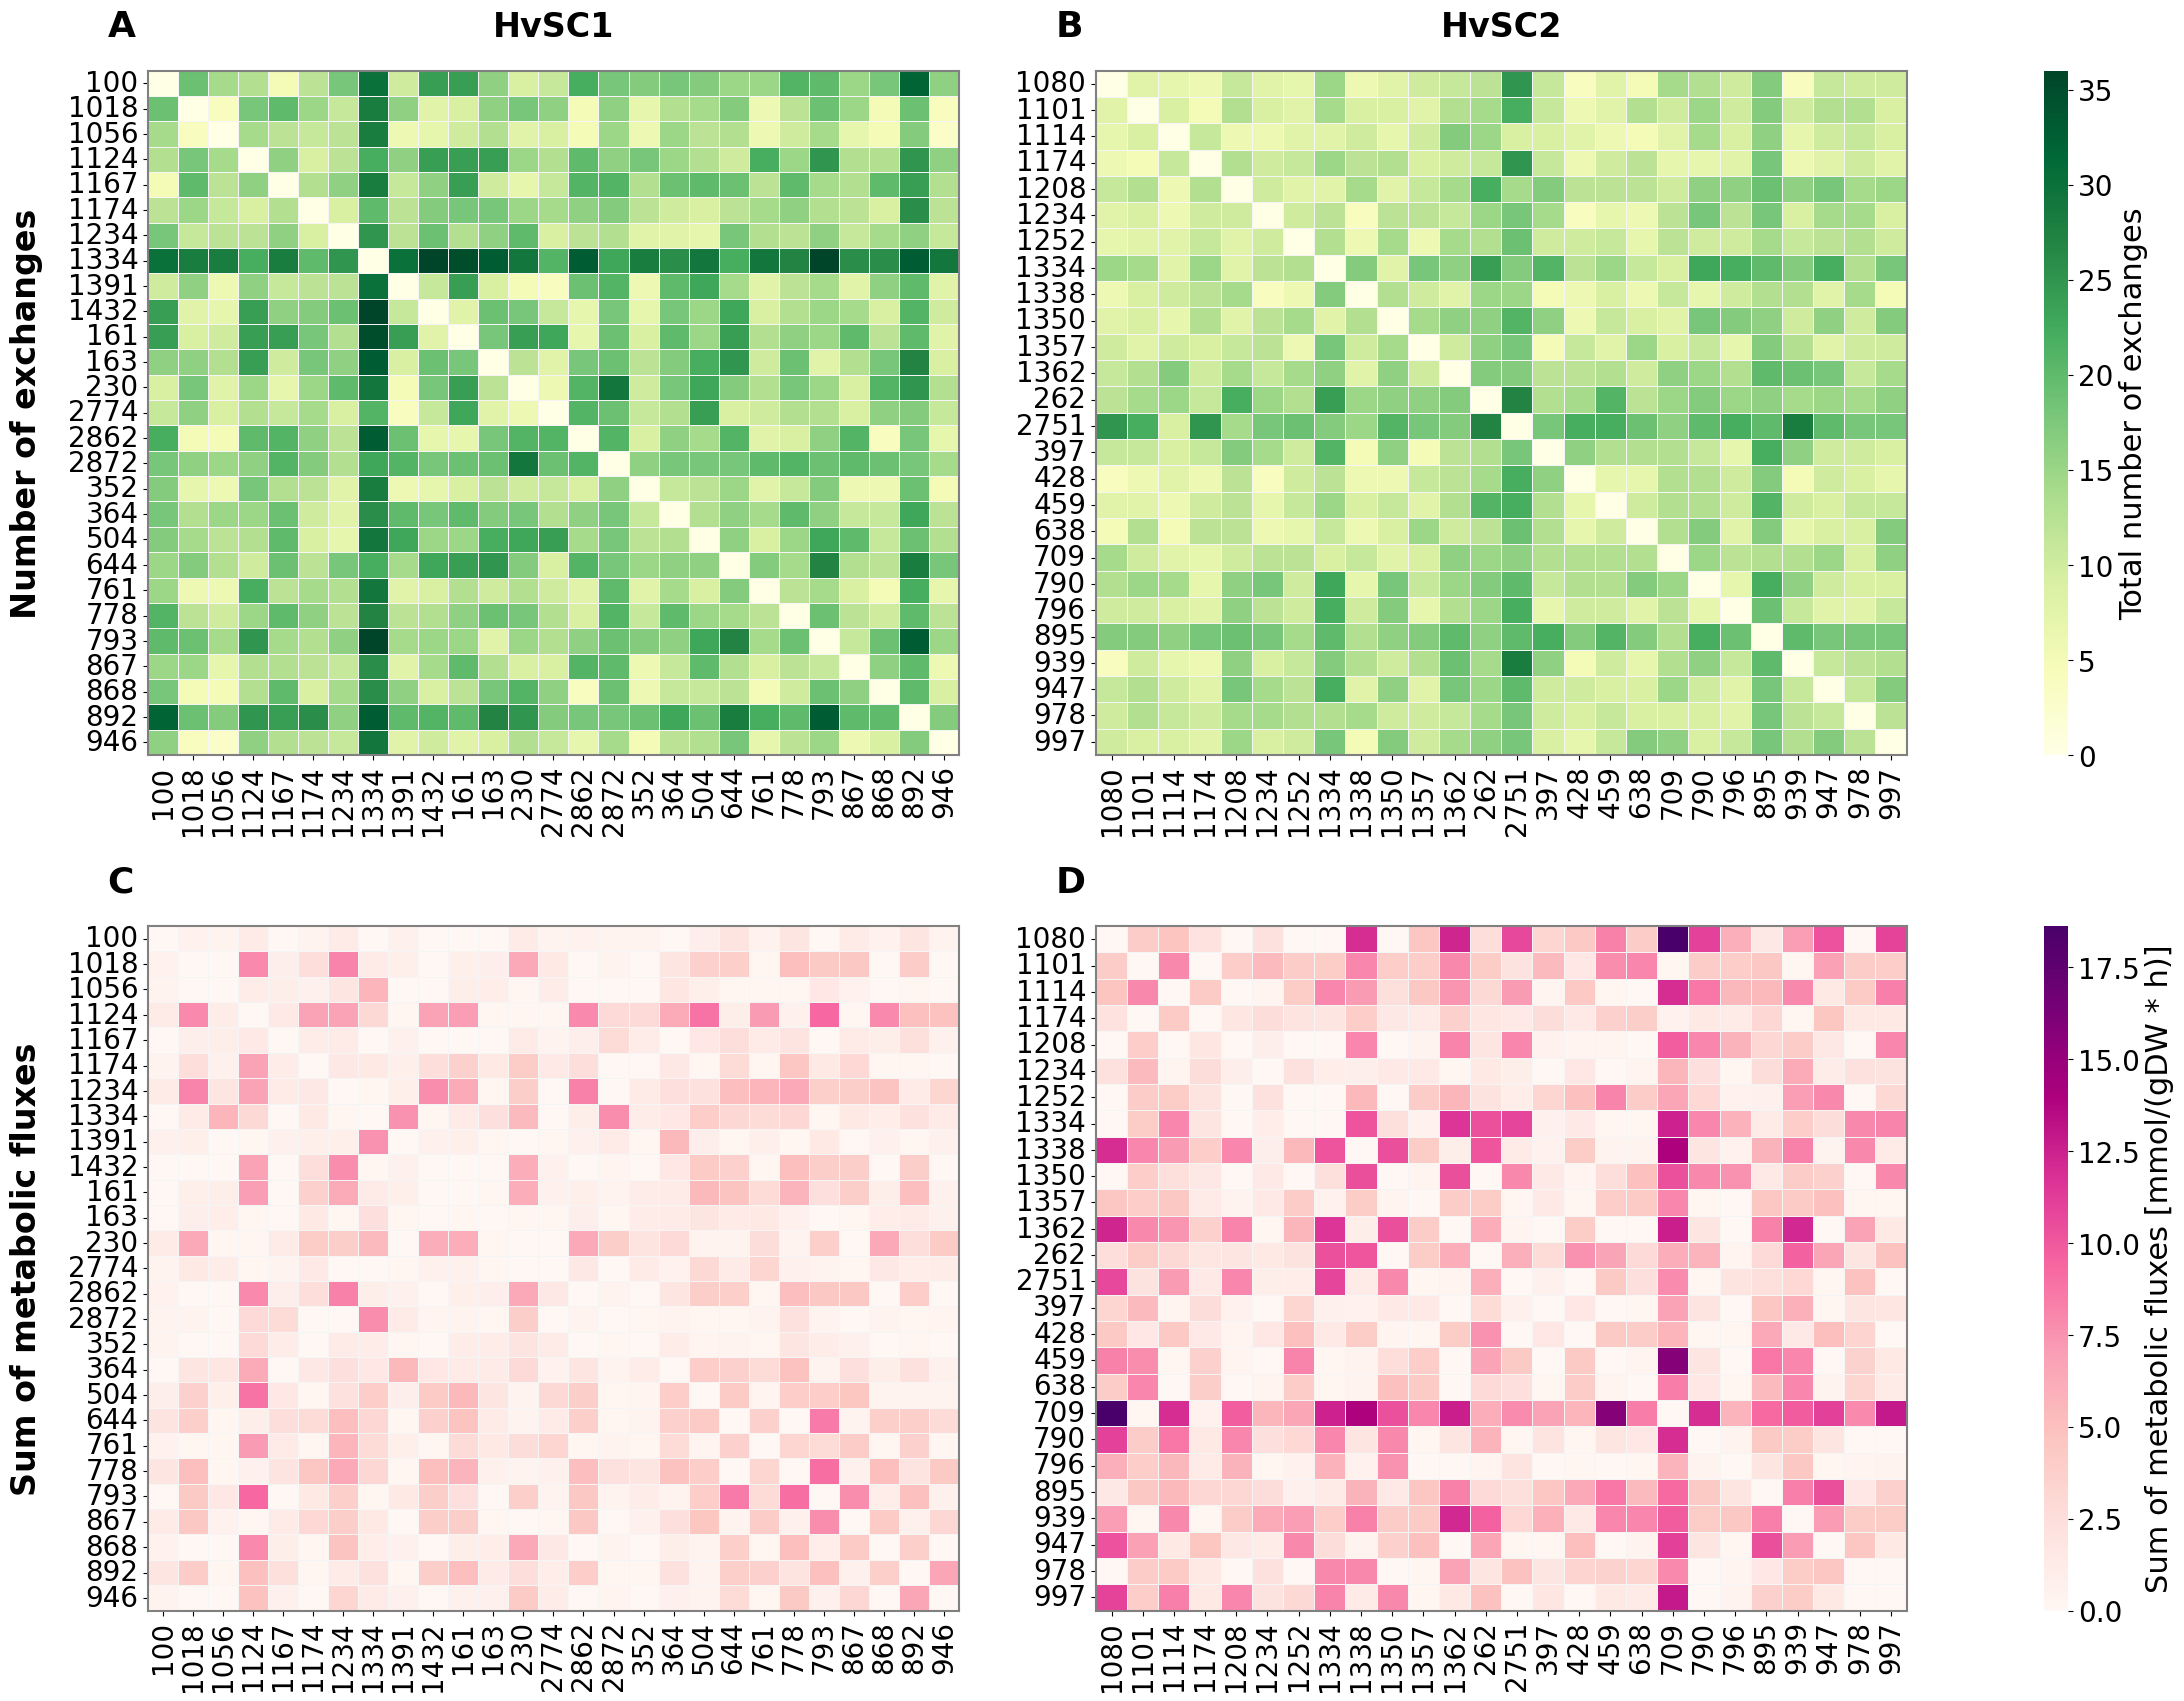

In [25]:
fig = plt.figure(figsize=(24, 20))
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.03], wspace=0.25, hspace=0.25)

ax11 = fig.add_subplot(gs[0, 0])
ax12 = fig.add_subplot(gs[0, 1])
cax1 = fig.add_subplot(gs[0, 2])

ax21 = fig.add_subplot(gs[1, 0])
ax22 = fig.add_subplot(gs[1, 1])
cax2 = fig.add_subplot(gs[1, 2]) 


#Plot Row 1: Number of Exchanges (NEX)
sns.heatmap(
    heatmap_nex_matrix1,
    ax=ax11,
    cmap="YlGn",
    vmin=min_nex_val,
    vmax=max_nex_val,
    cbar=False,
    linewidths=0.5,
    linecolor='whitesmoke'
)

sns.heatmap(
    heatmap_nex_matrix2,
    ax=ax12,
    cmap="YlGn",
    vmin=min_nex_val,
    vmax=max_nex_val,
    cbar=True,
    cbar_ax=cax1,
    cbar_kws={'label': 'Total number of exchanges'},
    linewidths=0.5,
    linecolor='whitesmoke'
)

#Plot Row 2: Sum of Fluxes (SumFlux)
sns.heatmap(
    heatmap_sumflux_matrix1,
    ax=ax21,
    cmap="RdPu",
    vmin=min_sumflux_val,
    vmax=max_sumflux_val,
    cbar=False,
    linewidths=0.5,
    linecolor='whitesmoke'
)

sns.heatmap(
    heatmap_sumflux_matrix2,
    ax=ax22,
    cmap="RdPu",
    vmin=min_sumflux_val,
    vmax=max_sumflux_val,
    cbar=True,
    cbar_ax=cax2,
    cbar_kws={'label': 'Sum of metabolic fluxes [mmol/(gDW * h)]'},
    linewidths=0.5,
    linecolor='whitesmoke'
)

all_axes = [ax11, ax12, ax21, ax22]
for ax in all_axes:
    ax.tick_params(labelsize=tick_size, axis="both")
    ax.set_xlabel("", fontsize=axis_labels)
    ax.set_ylabel("", fontsize=axis_labels)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('grey')
        spine.set_linewidth(1.5)

ax11.set_title("HvSC1", fontsize=subtitle_size, fontweight = "bold", pad=25)
ax12.set_title("HvSC2", fontsize=subtitle_size, fontweight = "bold", pad=25)

ax11.text(-0.15, 0.5, "Number of exchanges", transform=ax11.transAxes,
        fontsize=subtitle_size, va='center', fontweight = "bold", ha='center', rotation=90)

ax21.text(-0.15, 0.5, "Sum of metabolic fluxes", transform=ax21.transAxes,
        fontsize=subtitle_size, va='center', fontweight = "bold", ha='center', rotation=90)

# Subplot tags (A, B, C, D)
ax11.text(-0.05, 1.05, "A", transform=ax11.transAxes, fontsize=subtitle_size + 2, fontweight='bold')
ax12.text(-0.05, 1.05, "B", transform=ax12.transAxes, fontsize=subtitle_size + 2, fontweight='bold')
ax21.text(-0.05, 1.05, "C", transform=ax21.transAxes, fontsize=subtitle_size + 2, fontweight='bold')
ax22.text(-0.05, 1.05, "D", transform=ax22.transAxes, fontsize=subtitle_size + 2, fontweight='bold')

cax1.yaxis.label.set_size(legend_size)
cax1.tick_params(labelsize=tick_size)
cax2.yaxis.label.set_size(legend_size)
cax2.tick_params(labelsize=tick_size)

plt.subplots_adjust(left=0.1) 
#plt.savefig(os.path.join(save_fig_dir, "Combined_nex_sumflux_heatmap.svg"), bbox_inches='tight')
#plt.savefig(os.path.join(save_fig_dir, "Combined_nex_sumflux_heatmap.png"), bbox_inches='tight')
plt.show()

##### Symmetry of Pairwise Metabolic Interactions

In [26]:
# Only keep 'provided' class
df_prov1 = df_clean1[df_clean1["class"] == "provided"].copy()
df_prov2 = df_clean2[df_clean2["class"] == "provided"].copy()


pair_fluxes1 = df_prov1.groupby(['producer', 'consumer'], as_index=False)['flux'].sum()
pair_numberrxns1 = df_prov1.groupby(["producer", "consumer"], as_index=False)["reaction"].nunique()
pair_fluxes2 = df_prov2.groupby(['producer', 'consumer'], as_index=False)['flux'].sum()
pair_numberrxns2 = df_prov2.groupby(["producer", "consumer"], as_index=False)["reaction"].nunique()

#  merge fluxes 
right_fluxes1 = pair_fluxes1.rename(columns={
    'producer': 'consumer', 
    'consumer': 'producer', 
    'flux': 'flux_provided_by_B'})

trade_df1 = pd.merge(
    pair_fluxes1.rename(columns={'flux': 'flux_provided_by_A'}),
    right_fluxes1,
    on=['producer', 'consumer'],
    how='inner')

right_fluxes2 = pair_fluxes2.rename(columns={
    'producer': 'consumer', 
    'consumer': 'producer', 
    'flux': 'flux_provided_by_B'})

trade_df2 = pd.merge(
    pair_fluxes2.rename(columns={'flux': 'flux_provided_by_A'}),
    right_fluxes2,
    on=['producer', 'consumer'],
    how='inner')

trade_df1['balance'] = trade_df1['flux_provided_by_A'] - trade_df1['flux_provided_by_B']
heatmap_matrix1 = trade_df1.pivot(index='producer', columns='consumer', values='balance').fillna(0)

trade_df2['balance'] = trade_df2['flux_provided_by_A'] - trade_df2['flux_provided_by_B']
heatmap_matrix2 = trade_df2.pivot(index='producer', columns='consumer', values='balance').fillna(0)

# merge metabolite numbers
right_nrxn1 = pair_numberrxns1.rename(columns={
    'producer': 'consumer', 
    'consumer': 'producer', 
    'reaction': 'metabolite_provided_by_B'
})

trade_nrxn_df1 = pd.merge(
    pair_numberrxns1.rename(columns={'reaction': 'metabolite_provided_by_A'}),
    right_nrxn1,
    on=['producer', 'consumer'],
    how='inner'
)

trade_nrxn_df1['balance'] = trade_nrxn_df1['metabolite_provided_by_A'] - trade_nrxn_df1['metabolite_provided_by_B']
heatmap_matrix1rxn = trade_nrxn_df1.pivot(index='producer', columns='consumer', values='balance').fillna(0)

right_nrxn2 = pair_numberrxns2.rename(columns={
    'producer': 'consumer', 
    'consumer': 'producer', 
    'reaction': 'metabolite_provided_by_B'})

trade_nrxn_df2 = pd.merge(
    pair_numberrxns2.rename(columns={'reaction': 'metabolite_provided_by_A'}),
    right_nrxn2,
    on=['producer', 'consumer'],
    how='inner')

trade_nrxn_df2['balance'] = trade_nrxn_df2['metabolite_provided_by_A'] - trade_nrxn_df2['metabolite_provided_by_B']
heatmap_matrix2rxn = trade_nrxn_df2.pivot(index='producer', columns='consumer', values='balance').fillna(0)

# scale limits
min_val = min(heatmap_matrix1.values.min(), heatmap_matrix2.values.min())
max_val = max(heatmap_matrix1.values.max(), heatmap_matrix2.values.max())

min_valnrxn = min(heatmap_matrix1rxn.values.min(), heatmap_matrix2rxn.values.min())
max_valnrxn = max(heatmap_matrix1rxn.values.max(), heatmap_matrix2rxn.values.max())

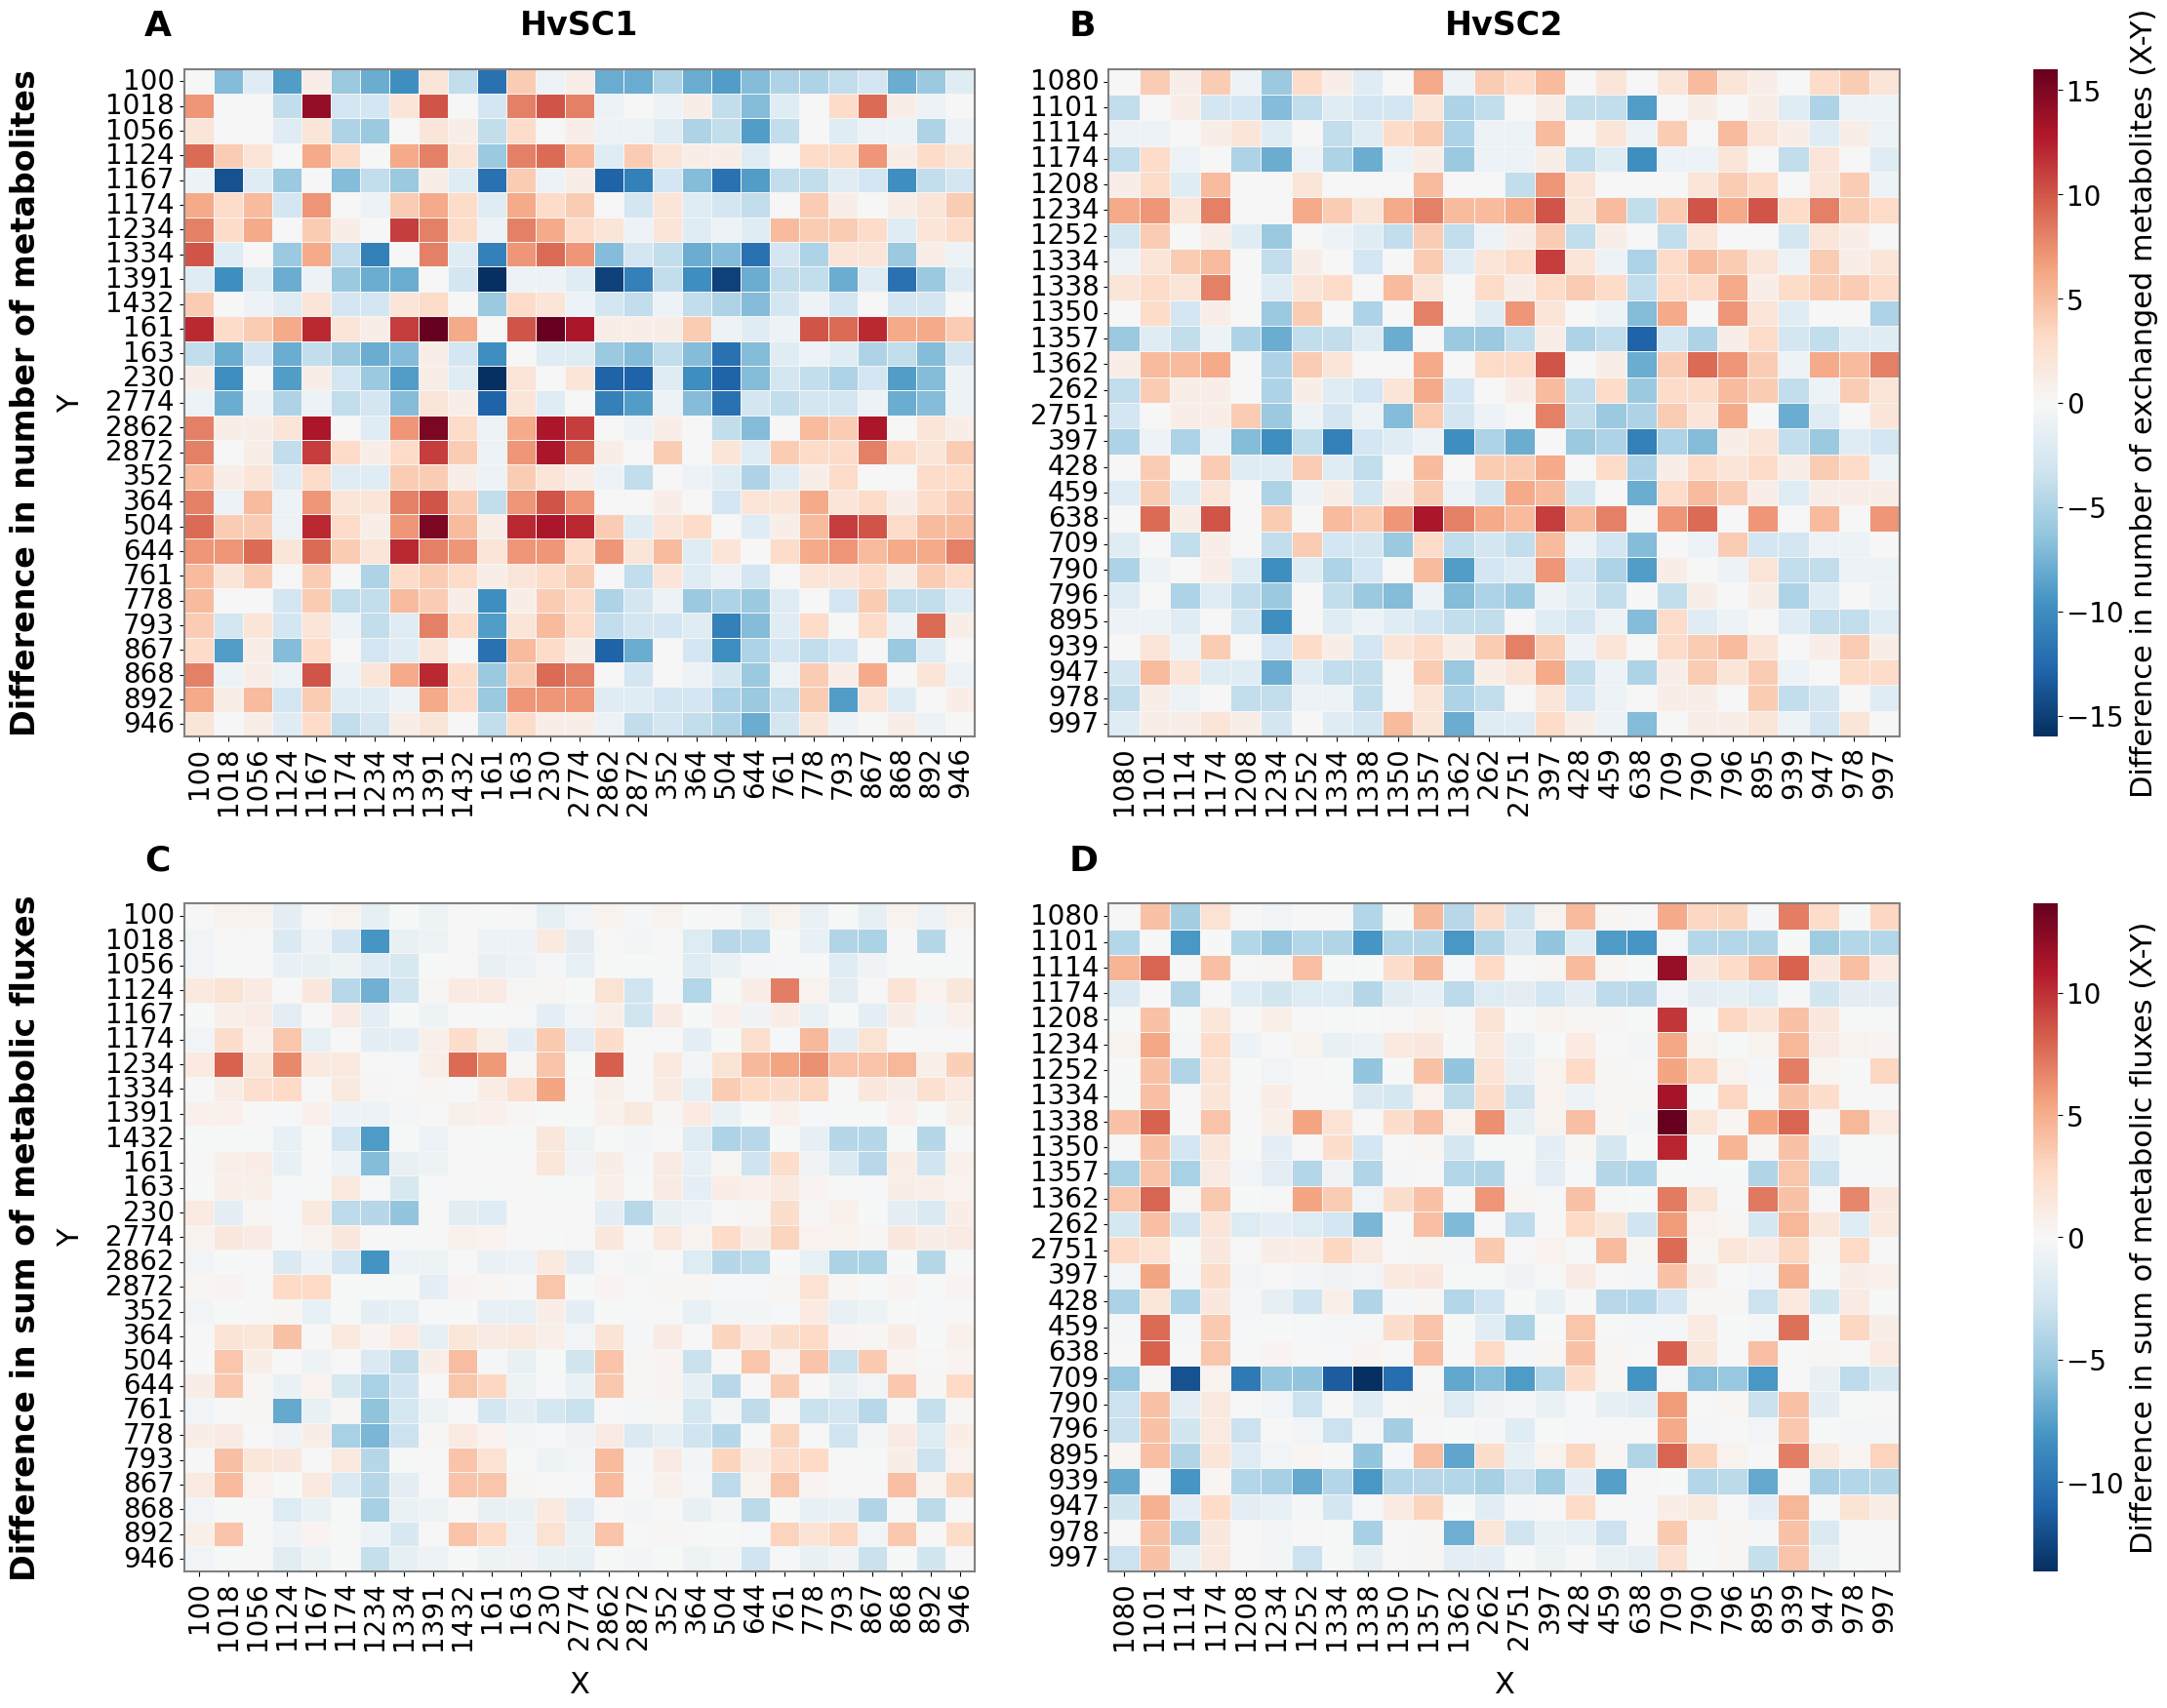

In [28]:
fig = plt.figure(figsize=(24, 20))
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.03], wspace=0.25, hspace=0.25)

# Row 1 Axes
ax11 = fig.add_subplot(gs[0, 0])
ax12 = fig.add_subplot(gs[0, 1])
cax1 = fig.add_subplot(gs[0, 2])  # Colorbar Row 1 (NEX)

# Row 2 Axes
ax21 = fig.add_subplot(gs[1, 0])
ax22 = fig.add_subplot(gs[1, 1])
cax2 = fig.add_subplot(gs[1, 2])  # Colorbar Row 2 (SumFlux)


# Number of exchanges
sns.heatmap(
    heatmap_matrix1, 
    ax=ax21,               
    cmap="RdBu_r",          
    robust=True,            
    vmin=min_val,               
    vmax=max_val,   
    cbar=False,             
    linewidths=0.5,         
    linecolor='whitesmoke')

sns.heatmap(
    heatmap_matrix2, 
    ax=ax22,               
    cmap="RdBu_r",          
    robust=True,            
    vmin=min_val,               
    vmax=max_val,   
    cbar=True,
    cbar_ax=cax2,
    cbar_kws={'label': 'Difference in sum of metabolic fluxes (X-Y)'},              
    linewidths=0.5,         
    linecolor='whitesmoke')

# Sum of fluxes
sns.heatmap(
    heatmap_matrix1rxn, 
    ax=ax11,               
    cmap="RdBu_r",          
    robust=True,            
    vmin=min_valnrxn,               
    vmax=max_valnrxn,   
    cbar=False,             
    linewidths=0.5,         
    linecolor='whitesmoke')

sns.heatmap(
    heatmap_matrix2rxn, 
    ax=ax12,               
    cmap="RdBu_r",          
    robust=True,            
    vmin=min_valnrxn,               
    vmax=max_valnrxn,   
    cbar=True,    
    cbar_ax=cax1,
    cbar_kws={'label': 'Difference in number of exchanged metabolites (X-Y)'},         
    linewidths=0.5,         
    linecolor='whitesmoke')

all_axes = [ax11, ax12, ax21, ax22]
for ax in all_axes:
    ax.tick_params(labelsize=tick_size, axis="both")
    ax.set_xlabel("", fontsize=axis_labels)
    ax.set_ylabel("", fontsize=axis_labels)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('grey')
        spine.set_linewidth(1.5)

ax21.set_xlabel("X", fontsize=axis_labels, labelpad=15)
ax22.set_xlabel("X", fontsize=axis_labels, labelpad=15)
ax11.set_ylabel("Y", fontsize=axis_labels, labelpad=15)
ax21.set_ylabel("Y", fontsize=axis_labels, labelpad=15)
ax11.set_title("HvSC1", fontsize=subtitle_size, fontweight = "bold", pad=25)
ax12.set_title("HvSC2", fontsize=subtitle_size, fontweight = "bold", pad=25)
ax11.text(-0.2, 0.5, "Difference in number of metabolites", transform=ax11.transAxes,
        fontsize=subtitle_size, va='center', fontweight='bold', ha='center', rotation=90)
ax21.text(-0.2, 0.5, "Difference in sum of metabolic fluxes", transform=ax21.transAxes,
        fontsize=subtitle_size, va='center',fontweight='bold', ha='center', rotation=90)

# Subplot tags (A, B, C, D)
ax11.text(-0.05, 1.05, "A", transform=ax11.transAxes, fontsize=subtitle_size + 2, fontweight='bold')
ax12.text(-0.05, 1.05, "B", transform=ax12.transAxes, fontsize=subtitle_size + 2, fontweight='bold')
ax21.text(-0.05, 1.05, "C", transform=ax21.transAxes, fontsize=subtitle_size + 2, fontweight='bold')
ax22.text(-0.05, 1.05, "D", transform=ax22.transAxes, fontsize=subtitle_size + 2, fontweight='bold')

# Format Colorbars
cax1.yaxis.label.set_size(legend_size)
cax1.tick_params(labelsize=tick_size)
cax2.yaxis.label.set_size(legend_size)
cax2.tick_params(labelsize=tick_size)

plt.subplots_adjust(left=0.1) 
#plt.savefig(os.path.join(save_fig_dir, "Combined_balance_nmets_flux_heatmap.svg"), bbox_inches='tight')
plt.savefig(os.path.join(save_fig_dir, "Combined_balance_nmets_flux_heatmap.png"), bbox_inches='tight')
plt.show()

## 4. Compare individual growth in monoculture to growth in community on complete medium

In [ ]:
# combine the complete media of all to a total complete medium, which we can later use for the community simulation
complete_medium = {}
model_growth_rates = {}
for file in os.listdir(model_dir):
    if file .endswith(".xml"):
        model = cobra.io.read_sbml_model(os.path.join(model_dir, file))
        solution = model.optimize()
        model_id = model.id.split("_")[1]
        model_growth_rates[model_id] = solution.objective_value
        print(f"Model: {model_id}, Growth rate: {solution.objective_value}")
        cur_med = model.medium
        for met, flux in cur_med.items():
            if met not in complete_medium:
                complete_medium[met] = flux
            else:
                if complete_medium[met] < flux:
                    complete_medium[met] = flux

Model: 2872, Growth rate: 39.79083907742365
Model: 761, Growth rate: 64.38903283581836
Model: 793, Growth rate: 67.65222467847445
Model: 892, Growth rate: 51.732600670951165
Model: 1334, Growth rate: 42.06620765086557
Model: 997, Growth rate: 69.85160471881468
Model: 1432, Growth rate: 79.76500136677335
Model: 2751, Growth rate: 33.74394540823529
Model: 428, Growth rate: 68.30818346980378
Model: 1252, Growth rate: 50.19953581084187
Model: 459, Growth rate: 77.33361702291404
Model: 262, Growth rate: 63.140612268267084
Model: 1101, Growth rate: 66.021351190538
Model: 868, Growth rate: 67.83794992629912
Model: 1362, Growth rate: 68.57412960843085
Model: 1350, Growth rate: 39.03631263033623
Model: 161, Growth rate: 63.68269227208385
Model: 1167, Growth rate: 43.741180356451785
Model: 1391, Growth rate: 65.04306572102819
Model: 2862, Growth rate: 43.633827606569454
Model: 709, Growth rate: 83.10447836190441
Model: 978, Growth rate: 40.02942955233443
Model: 867, Growth rate: 57.4087946909311

In [ ]:
# test growth of community on complete medium
complete_medium_micom = {(k[:-2] + "_m" if k.endswith("_e") else k): v for k, v in complete_medium.items()}
HvSC1.medium = complete_medium_micom
HvSC2.medium = complete_medium_micom

solution_HvSC1 = HvSC1.optimize()
solution_HvSC2 = HvSC2.optimize()

In [ ]:
for model in solution_HvSC1.members.index:
    if model != "medium":
        print(f"Model: {model}, µi in community: {solution_HvSC1.members.loc[model, 'growth_rate']}, µi in monoculture: {model_growth_rates[model]}, difference µi: {solution_HvSC1.members.loc[model, 'growth_rate'] - model_growth_rates[model]}")

Model: 100, µi in community: 34.90744408872803, µi in monoculture: 54.53363608890081, difference µi: -19.626192000172786
Model: 1018, µi in community: 44.854258187395445, µi in monoculture: 63.37629448134004, difference µi: -18.522036293944595
Model: 1056, µi in community: 35.20397924436133, µi in monoculture: 50.91502176511579, difference µi: -15.71104252075446
Model: 1124, µi in community: 33.22105067331546, µi in monoculture: 53.46787178934061, difference µi: -20.246821116025153
Model: 1167, µi in community: 27.93245085954576, µi in monoculture: 43.741180356451785, difference µi: -15.808729496906025
Model: 1174, µi in community: 28.947397279484775, µi in monoculture: 58.88615046167985, difference µi: -29.93875318219507
Model: 1234, µi in community: 48.2592781773904, µi in monoculture: 83.42948956368647, difference µi: -35.170211386296074
Model: 1334, µi in community: 35.287665045450524, µi in monoculture: 42.06620765086557, difference µi: -6.778542605415048
Model: 1391, µi in commun

In [ ]:
for model in solution_HvSC2.members.index:
    if model != "medium":
        print(f"Model: {model}, µi in community: {solution_HvSC2.members.loc[model, 'growth_rate']}, µi in monoculture: {model_growth_rates[model]}, difference µi: {solution_HvSC2.members.loc[model, 'growth_rate'] - model_growth_rates[model]}")

Model: 1080, µi in community: 36.24333042470382, µi in monoculture: 68.24216441762108, difference µi: -31.998833992917262
Model: 1101, µi in community: 34.64846678653544, µi in monoculture: 66.021351190538, difference µi: -31.372884404002562
Model: 1114, µi in community: 25.487908503561307, µi in monoculture: 32.27855121799641, difference µi: -6.790642714435101
Model: 1174, µi in community: 28.947397279484722, µi in monoculture: 58.88615046167985, difference µi: -29.938753182195125
Model: 1208, µi in community: 30.10639378901769, µi in monoculture: 51.113557841401175, difference µi: -21.007164052383484
Model: 1234, µi in community: 48.25927817739037, µi in monoculture: 83.42948956368647, difference µi: -35.1702113862961
Model: 1252, µi in community: 18.103986828014403, µi in monoculture: 50.19953581084187, difference µi: -32.09554898282747
Model: 1334, µi in community: 35.2876650454505, µi in monoculture: 42.06620765086557, difference µi: -6.778542605415069
Model: 1338, µi in community